In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from math import sqrt

In [3]:
df = pd.read_csv("exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [5]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [6]:
df.isnull().sum()

,0
date,0
Ex_rate,0


# Data Preparation and Exploration

The exchange rate dataset was loaded using Pandas.

The following preprocessing steps were performed:
- Checked dataset information
- Verified missing values
- Explored the structure of the dataset

This helps understand trends and prepare data
for forecasting.

In [8]:
print(df.columns)

Index(['date', 'Ex_rate'], dtype='object')


In [10]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['date', 'Ex_rate'], dtype='object')


In [12]:
print(df['date'].head(20))

0     01-01-1990 00:00
1     02-01-1990 00:00
2     03-01-1990 00:00
3     04-01-1990 00:00
4     05-01-1990 00:00
5     06-01-1990 00:00
6     07-01-1990 00:00
7     08-01-1990 00:00
8     09-01-1990 00:00
9     10-01-1990 00:00
10    11-01-1990 00:00
11    12-01-1990 00:00
12    13-01-1990 00:00
13    14-01-1990 00:00
14    15-01-1990 00:00
15    16-01-1990 00:00
16    17-01-1990 00:00
17    18-01-1990 00:00
18    19-01-1990 00:00
19    20-01-1990 00:00
Name: date, dtype: object


In [13]:
df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce'
)

In [14]:
print(df['date'].isnull().sum())

4590


In [15]:
df = df.dropna(subset=['date'])

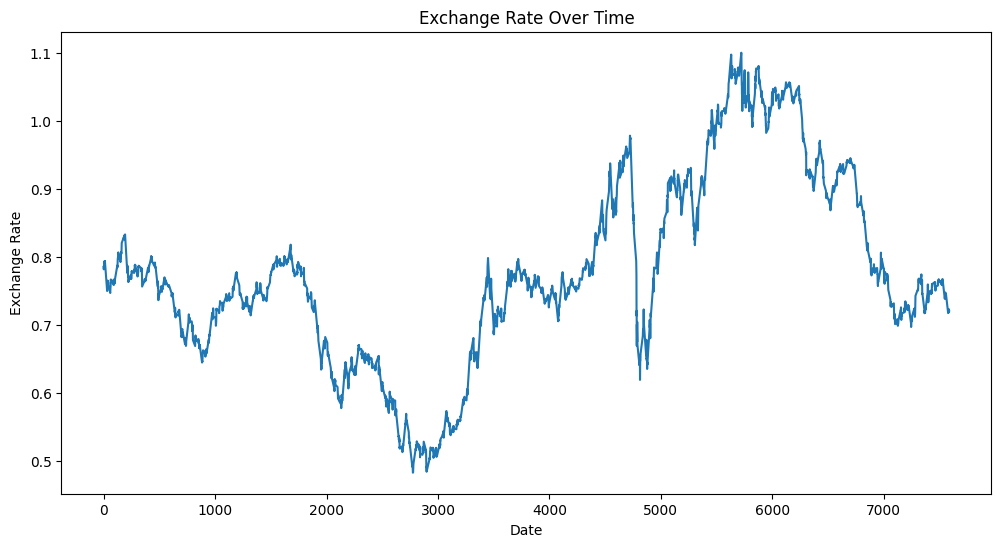

In [16]:
plt.figure(figsize=(12,6))

plt.plot(df['Ex_rate'])

plt.title("Exchange Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Exchange Rate")

plt.show()

# Time Series Visualization

The exchange rate values were plotted over time
to observe trends and fluctuations.

Visualization helps identify:
- Trends
- Seasonality
- Sudden changes
- Anomalies

In [17]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_15171/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [18]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

print(train.shape)

print(test.shape)

(2398, 2)
(600, 2)


# Train-Test Split

The dataset was divided into:
- 80% training data
- 20% testing data

Training data is used to train the model,
while testing data evaluates forecasting performance.

In [19]:
model = ARIMA(
    train['Ex_rate'],
    order=(1,1,1)
)

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 2398
Model:                 ARIMA(1, 1, 1)   Log Likelihood                8008.128
Date:                Wed, 20 May 2026   AIC                         -16010.257
Time:                        06:27:44   BIC                         -15992.911
Sample:                             0   HQIC                        -16003.946
                               - 2398                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1106      0.463     -0.239      0.811      -1.018       0.796
ma.L1          0.0776      0.467      0.166      0.868      -0.837       0.992
sigma2       7.34e-05   6.57e-07    111.652      0.0

# ARIMA Model

ARIMA model was used for time series forecasting.

The parameters:
- p = autoregressive order
- d = differencing order
- q = moving average order

ARIMA captures temporal dependencies
in exchange rate data.

In [20]:
forecast = model_fit.forecast(
    steps=len(test)
)

print(forecast)

2398    1.022510
2399    1.022522
2400    1.022521
2401    1.022521
2402    1.022521
          ...   
2993    1.022521
2994    1.022521
2995    1.022521
2996    1.022521
2997    1.022521
Name: predicted_mean, Length: 600, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


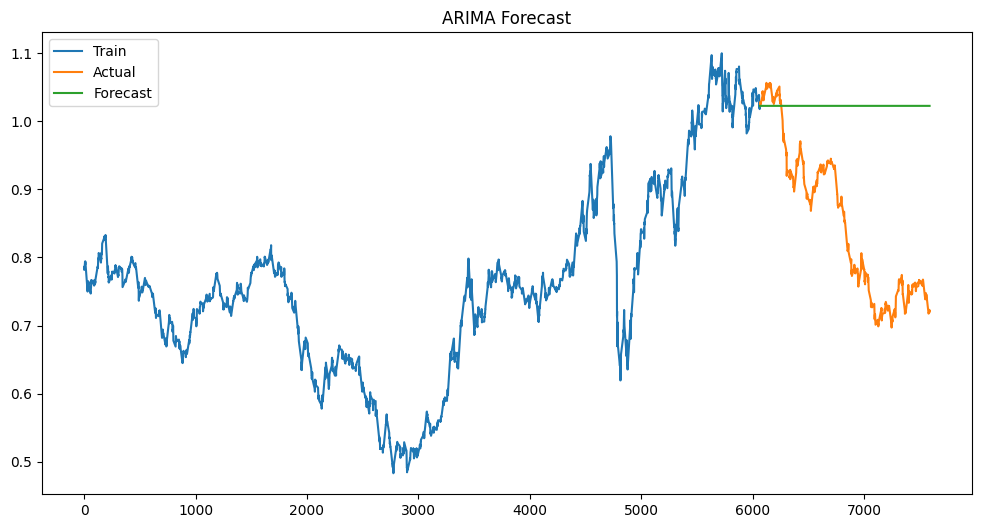

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Ex_rate'],
    label='Train'
)

plt.plot(
    test.index,
    test['Ex_rate'],
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

# Forecast Visualization

The forecasted exchange rates were plotted
against actual values.

This visualization helps compare:
- Model predictions
- Actual exchange rate movements

In [22]:
mae = mean_absolute_error(
    test['Ex_rate'],
    forecast
)

print("MAE:", mae)

MAE: 0.17792617066912939


In [23]:
rmse = sqrt(
    mean_squared_error(
        test['Ex_rate'],
        forecast
    )
)

print("RMSE:", rmse)

RMSE: 0.2055214469058557


In [24]:
mape = np.mean(
    np.abs(
        (test['Ex_rate'] - forecast)
        / test['Ex_rate']
    )
) * 100

print("MAPE:", mape)

MAPE: nan


# Error Metrics

The following metrics were used to evaluate model performance:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

Lower values indicate better forecasting accuracy.

Model Evaluation

ARIMA forecasting model was evaluated
using error metrics.

The model performance depends on:
- Parameter selection
- Trend behavior
- Dataset stationarity

Lower MAE, RMSE, and MAPE values
indicate better forecasting performance.

Model Evaluation

ARIMA forecasting model was evaluated
using error metrics.

The model performance depends on:
- Parameter selection
- Trend behavior
- Dataset stationarity

Lower MAE, RMSE, and MAPE values
indicate better forecasting performance.

Conclusion

In this assignment, time series forecasting
was performed using the ARIMA model.

The dataset was preprocessed and analyzed
to identify patterns and trends.

ARIMA successfully forecasted future exchange rates.

Forecast accuracy was evaluated using:
- MAE
- RMSE
- MAPE